# Mathematics for Data Science Foundation

This is my extension of the article by Farzad Nobar on data science foundations. The article from Towards Data Science lists a bunch of foundational mathematics needed for data science including:

1. Statistics
2. Calculus
3. Linear Algebra
4. Probability

I liked the article so much I decided to extend it a little further.

## 1. Statistics
Starting with statistics

### 1.1 Descriptive statistics

Simply put this refers to ways of summarising and intepreting data.

Here I'm going to use the number of children born from a 1941 Canadian census to Protestant mothers in Ontario:

0 4 0 2 3 3 0 4 7 1 9 4 3 2 3 2 16 6 0 13 6 6 5 9 10 5 4 3 3 5 2 3 5 15 5

In [4]:
import numpy as np
import pandas as pd

#create data set i.e. a key value dictionary with the value as a list of numbers
numofchildren = {'Values': [0,4,0,2,3,3,0,4,7,1,9,4,3,2,3,2,16,6,0,13,6,6,5,9,10,5,4,3,3,5,2,3,5,15,5]}

#create a dataframe of the dataset
df = pd.DataFrame(numofchildren)

# calculate descriptive statistics
mean = df['Values'].mean()
median = df['Values'].median()
std_dev = df['Values'].std()

print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Standard Deviation: {std_dev}")

Mean: 4.8
Median: 4.0
Standard Deviation: 3.9541489751458605


We can see that the mean and median number of children are not very close which means that the data is slightly skewed the right (Mean > Median). We can even plot the data to see this. The standard deviation tells us that there are big differences in the number of children between anyone mother i.e. the standard deviation tells us how clustered around the mean the data points are.

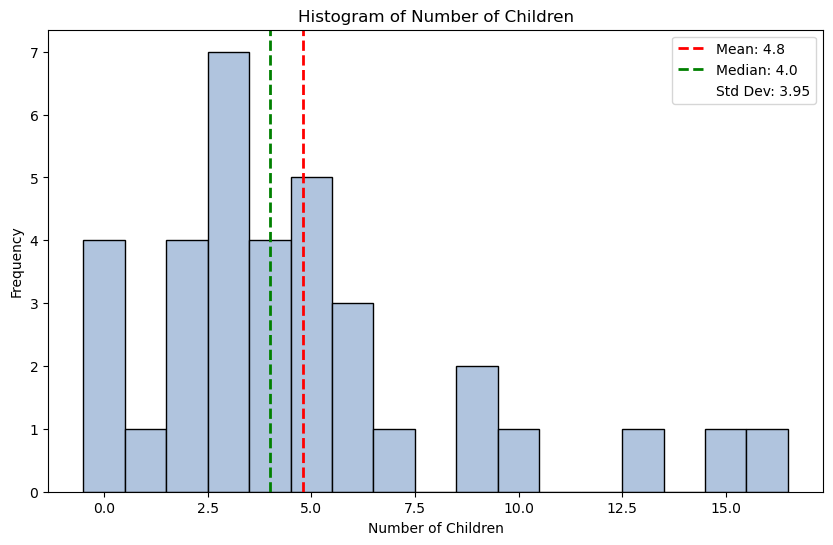

In [11]:
import matplotlib.pyplot as plt

# Your data
numofchildren = {'Values': [0,4,0,2,3,3,0,4,7,1,9,4,3,2,3,2,16,6,0,13,6,6,5,9,10,5,4,3,3,5,2,3,5,15,5]}
values = numofchildren['Values']

# statistics
mean_val = 4.8
median_val = 4.0
std_val = 3.95

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(values, bins=range(0, int(max(values)) + 2), edgecolor='black', align='left', color='lightsteelblue')

# Add a vertical line for the Mean
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val}')

# Add a vertical line for the Median
plt.axvline(median_val, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_val}')

# Add the Standard Deviation to the legend
# Create a "blank" plot entry just to show the text in the legend
plt.plot([], [], ' ', label=f'Std Dev: {std_val}')

# Labeling the graph
plt.xlabel("Number of Children")
plt.ylabel("Frequency")
plt.title("Histogram of Number of Children")

# Show the legend so we can see what the lines represent
plt.legend()

plt.show()

### 1.2 Inferential statistics

Inferential statistics is exactly what you think it means; infering from data some form of conclusion or judgement specifically extrapolating from 
a sample of data something about a population. It is usually impractical to try and measure some attribute from a population that could be in the
thousands, millions or even billions.

The process, briefly explained,  involves overlaying a well known statistical model to sample data in order to help answer questions about a population. Most common basic models are: Normal distribution, Exponential distribution, Poison distribution, Bernoulli distribution etc.

I managed to find some data on "the average heights and weights for American women aged between 30 to 39" from Wolfram Data Repository:

| Height | Weight |
| --- | --- |
| 58 in | 115 lb |
| 59 in | 117 lb |
| 58 in | 120 lb |
| 59 in | 123 lb |
| 60 in | 126 lb |
| 61 in | 129 lb |
| 62 in | 132 lb |
| 63 in | 135 lb |
| 64 in | 139 lb |
| 65 in | 142 lb |
| 66 in | 142 lb |
| 67 in | 146 lb |
| 68 in | 150 lb |
| 69 in | 154 lb |
| 70 in | 159 lb |
| 71 in | 155 lb |
| 72 in | 164 lb |

I want to infer something from this sample data about the general population from which the data was taken from namely the mean and the 95% confidence interval around the mean i.e. the range of the mean within a 95% confidence interval.



In [14]:
import numpy as np
import scipy.stats as stats

w_height = [58, 59, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72]
confidence_level = 0.95
mean = round(np.mean(w_height), 3)
sem = stats.sem(w_height) # standard error i.e. standard deviation of a sample mean
confidence_interval = stats.t.interval(confidence_level, len(w_height)-1, loc=mean, scale=sem)
rounded_ci = (round(confidence_interval[0], 4), round(confidence_interval[1], 4))

print(f"Mean: {mean}")
print(f"95% Confidence Interval: {rounded_ci}")


Mean: 64.235
95% Confidence Interval: (np.float64(61.813), np.float64(66.657))


So the average height of American women aged 30-39 is 64 inches and the 95% confidence interval implies that we are 95% confident that the true population mean of womens height in that cohort lies between 61.81 and 66.66. 

Actually what the 95% confidence interval really means is that if the sampling procedure were repeated a large number of times, then about 5% of the intervals generated completely miss the population mean i.e. the population mean would not be found in the particular instance i.e. the population mean would be outside that interval

# 1.3 Sampling

It's not practical to gather all the data from a population hence taking a sample from a population to understand something about that population is the more realistic and practical scenario. We want to ensure that the sample we take is representative as best as is possible of the population we are taking the sample from.

The most common sampling methodology are listed below:

- <b>Simple Random Sampling or SRS</b>:
  This just means collecting a random sample from a population. It could be by labelling and then randomising those labels so that each member of the population as an equal chance of being picked. However, it should be noted that using this method does not gurranttee a random sample as the population may not be randomly balanced for some characteristics that we are looking for e.g. age
- <b>Stratified Sample</b>:
  This technique can overcome some of the shortcomings in the SRS technique when sampling from a population i.e. preventing unwanted biases. For example, when sampling a population of people the population can be divided into subgroups called strata (e.g. age, gender etc) and a sample taken from each strata. This ensures each subgoup is represented in the sample and we don't get biased or unrepresentative samples from a population.
- <b>Systematic Sampling</b>: This technique involves taking every nth member of the population and is suitable for large populations with minimal  variations. In order to carry out this technique determine the sample size and the population size, divide the population size by the sample size which gives the interval. The interval is then used for 'every nth' e.g. from a population of 1000 with a sample size of 100 means chosing every 10th item from an ordered population list starting randomly anywhere between 1 and 10.

Here is an example of random sampling from a population size of 1000

In [5]:
import numpy as np

# create a population f 1000 values i.e. return a numpy array numbered from 1 to 1000
population  = np.arange(1, 1001)
# print(population)
# select a random sample of 10 values
sample = np.random.choice(population, size=10, replace=False)
print(f"Randon sample {sample}")


Randon sample [428 752 269 373  99 977 280 172 309 463]


Here is an exampe of systematic sampling with a population size of 1000 and a sample size of 100

In [13]:
import numpy as np

population_size = 1000
sample_size = 100

# create a population as a list from 1 to 1000
population = list(range(1, population_size + 1))

# Calculate the k sampling interval
k = population_size // sample_size

# Now randomly select a starting point between 1 and 10 
# Set the seed so as to get the same starting_point everytime the code is run
np.random.seed(42)
starting_point = np.random.randint(0, k) 

# Select every nth item from from the population starting from the starting_point
samples = [population[i] for i in range(starting_point, population_size, k)]
print(f"Every {k} element from population: \n {samples}")

Every 10 element from population: 
 [7, 17, 27, 37, 47, 57, 67, 77, 87, 97, 107, 117, 127, 137, 147, 157, 167, 177, 187, 197, 207, 217, 227, 237, 247, 257, 267, 277, 287, 297, 307, 317, 327, 337, 347, 357, 367, 377, 387, 397, 407, 417, 427, 437, 447, 457, 467, 477, 487, 497, 507, 517, 527, 537, 547, 557, 567, 577, 587, 597, 607, 617, 627, 637, 647, 657, 667, 677, 687, 697, 707, 717, 727, 737, 747, 757, 767, 777, 787, 797, 807, 817, 827, 837, 847, 857, 867, 877, 887, 897, 907, 917, 927, 937, 947, 957, 967, 977, 987, 997]


## 2. Calculus
Before discussing Calculus first something about functions that would be helpful.

<b>A little bit about functions...</b>

-------------------------------------------------------------------------------------------------------------------------------------------------------
You need functions to work on when using Calculus and most natural phenomena around us can be modelled as functions. Furthermore, functions take in inputs, apply a process and spit out an output. And if we can define a function for a process we can get more insights about a process which can be used to make predictions, describe that process etc.

Mathematicians define functions very strictly and are interested in the relationship of change between one variable and another e.g. the relationship between y and x. They have thus defined functions as:

1. Having an input (domain) into the function which has exactly one output (codomain) <b>and not more</b> i.e it is a one to one mapping between input and output i.e. you cannot have one input mapped to more than one output. This should be quite intuitive as to why this is the case and there's no need to overthink.
2. Some outputs (codomain) do not necessarily have to result from an input to a function i.e. some outputs are always excluded for example the function $f(x)=x^2$ excludes all negative numbers as its output.

An example of a more invloved function is: $s = ut + \frac{1}{2}at^2$. This is the relationship in Physics between displacement $s$ (a vector quantity that ignores distance and considers on how much something has moved from point a to point b by a straight line) and time $t$ with a constant term $a$ for acceleration due to gravity. 

This is a quadratic function because of the power of 2 on the $t$ variable. 

For example, if you throw a ball directly upwards with a known initial velocity $u$ you could technically figure out how high it would reach at any point in time. Since the function is a quadratic you could calculate at what time it would reach it's maximum height or at what time it would hit the ground (in the later simply solving the quadratic eqaution as you would when you were at school by equating the equation to zero (*because displacement equal to zero is when the ball has landed on the ground*) $s = ut + \frac{1}{2}at^2 = 0$ and solving for $t$).

An interesting fact is that if you differentiate (*see Derivatives below*) $s = ut + \frac{1}{2}at^2$ that leads to the equation for calculating the velocity of the ball as: $v = u + at$. If you differentiate the displacement function a second time (known as the second derivative) you will have an equation for acceleration which is $\dfrac{dv}{dt} = a$ or $v'(t) =a(t)$

-------------------------------------------------------------------------------------------------------------------------------------------------------
Machine learning systems work in simplified terms on maximising or minimising some given objective function especially when it is training i.e. optimising it for a given task. The first derivative gives the rate of change of one variable (input) against another variable (output) and the maximum and minimum points can be determined from the first derivative too (since that is the point when the rate equals 0 and by solving a derivative function at $f(x)'=0$ we can get the minimum or maximum value) and the machine then figures out by trial and error (with training) which steps will get it to that optimised (minimum or maximum) value (a process called gradient descent). **In particular the main goal is to find the minimum of the error function, which represents the difference between predicted and actual values.**

### 2.1 Derivatives

A derivative (some of which has been discussed above) is function which can be used to workout the rate of change of one variable with regards to another variable and the process of working out a derivative is called differentiation. 

You don't need differentition for a linear function because the rate of change is constant and can just be worked out by dividing y by x. However the blessings of defferentiation come when trying to understand non-linear functions where the rate if change is not constant but varies along the entirety of the function (dividing y by x would only give you the average rate of change not a specific or instantaneous rate of change at a particular x).

As already mentioned first derivatives can be used to work out a maximum or a minimum value of a function and this can be useful in machine learning because a machine is trying to get to this optimum (maximum or minimum) value and by extension the optimum output.

A quick example of using Python to find the derivative of a simple function is shown below.

The simple function is: $f(x)=x^2 + 2x +1$ and it plotted in Python for reference.

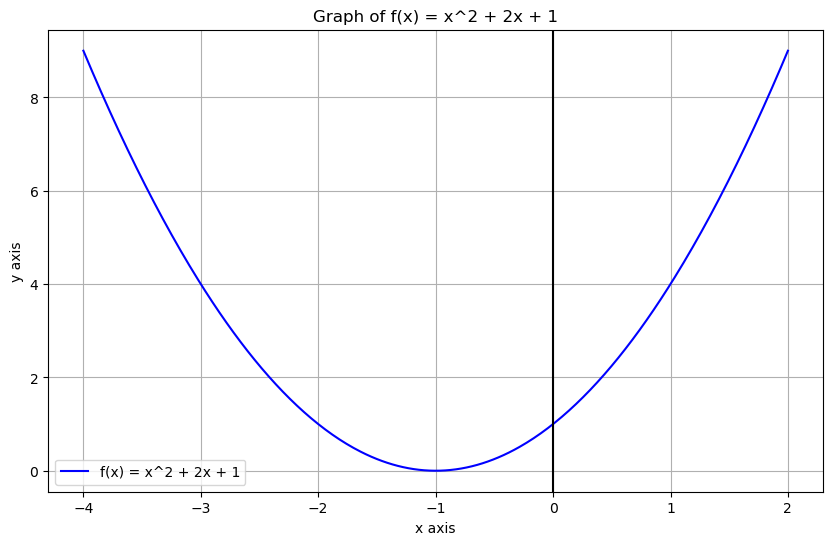

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Define the range of x values using np.linespace: np.linspace creates 400 points between -5 and 3
x = np.linspace(-4, 2, 400)

# Define the function y = x^2 + 2x + 1
y = x**2 + 2*x + 1

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='f(x) = x^2 + 2x + 1', color='blue')
plt.axvline(x = 0, color = 'k')

# Add labels and a title
plt.title('Graph of f(x) = x^2 + 2x + 1')
plt.xlabel('x axis')
plt.ylabel('y axis')

# Turn on grid
plt.grid(True)

# Show the legend and the plot
plt.legend()
plt.show()

**Using sympy diff() function in calculation the derivative of the function above**

In [3]:
import sympy as sp

# define the variable x and function f(x)
x = sp.Symbol('X')
f = x**2 + 2*x + 1
print(f"f(x)= {f}\n")

# calculate the derivative
derivative = sp.diff(f, x)

print("Derivative of f(x):")
print(derivative)


f(x)= X**2 + 2*X + 1

Derivative of f(x):
2*X + 2


### 2.2 Gradient Descent

So gradient descent is an iterative optimisation algorithm that gets a machine closer and closer to the minimum or maximum point by using:

1. An estimate (guess) of a value which you want to reduce to 0 i.e. your starting point
2. The derivate of the function
3. And a learning rate i.e. the step size to iterated to get to 0

<b>Illustration with example function</b>:

1. Take the function: $f(x) = (x-3)^2$; it's a parabola as illustrated below in Python.

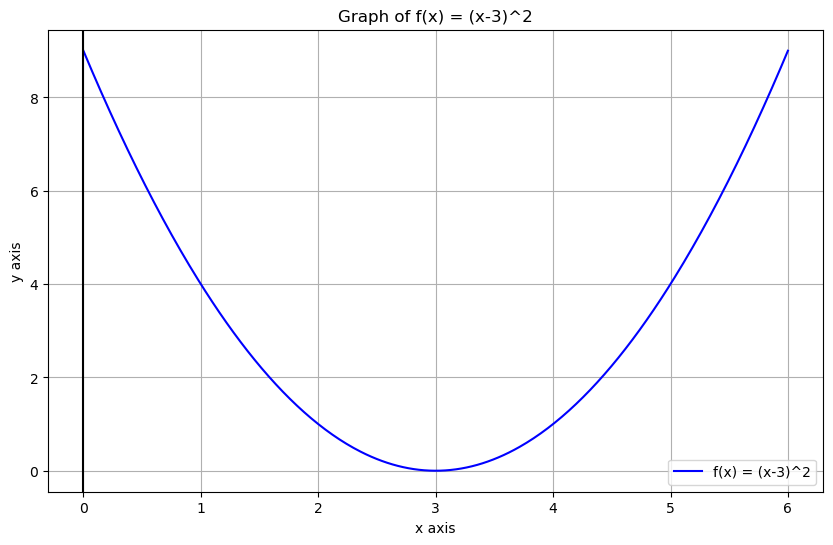

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Define the range of x values using np.linespace: np.linspace creates 400 points between -5 and 3
x = np.linspace(0, 6, 400)

# Define the function y = x^2 + 2x + 1
y = (x-3)**2

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='f(x) = (x-3)^2', color='blue')

# Add labels and a title
plt.title('Graph of f(x) = (x-3)^2')
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.axvline(x = 0, color = 'k')

# Turn on grid
plt.grid(True)

# Show the legend and the plot
plt.legend()
plt.show()

2. Take it's derivative: $f(x)' = 2(x-3)$
3. Choose an initial estimate for $x_0$ e.g. $x_0 = 0$ and learning rate $\eta>0$ e.g. $\eta=0.1$
4. Then iteratively apply the update rule to reach the value of approximately: $x_{n+1} \;=\; x_n \;-\;\eta\,f'(x_n)\;=\;x_n \;-\;2\eta\,(x_n-3)$

Gradient descent in Python looks like the following below. 

The point is there is a complex function and we don't know where it's minimum value is (the above function was a simple one which could be worked out by hand) and we guessed a starting value of $x = 0$ and worked our way iteratively to a value of $x = 3$.

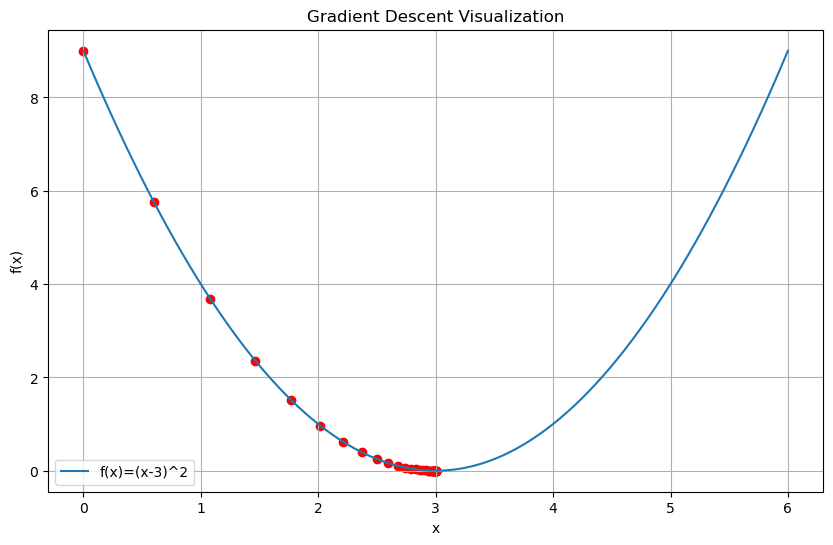

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# define the function and its derivative
def f(x):
    return (x-3)**2
def df(x):
    return 2*(x-3)

# define the initial estimate and learning rate
x = 0 # inital estimate
learning_rate = 0.1
n_iterations = 50

# perform gradient descent
x_values = [x]
for _ in range(n_iterations):
    gradient =df(x)
    x = x - learning_rate * gradient
    x_values.append(x)

# plot the function and descent path
x_range = np.linspace(0, 6, 100)
y_range = f(x_range)
plt.figure(figsize=(10, 6))
plt.plot(x_range, y_range, label='f(x)=(x-3)^2')
plt.scatter(x_values, [f(i) for i in x_values], color='red')
plt.title('Gradient Descent Visualization')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Linear Algebra

Linear algebra is kind of hard to define even though everyone has heard of it. For the purposes of this piece Linear Algebra is a branch of mathematics that grew out of the solution of systems of linear equations. By having the linear equations in matrix forms then all the operations known to matrices can be used to solve those equations.

Linear algebra lies at the heart of many machine learning models such as neural networks.

Some useful applications of matrices:

1. <u>Computer Science</u>: <br>

   **a**. Vectorised code (array programming) i.e. using linear algebra to compute many values simultaneously e.g. using matrices is much faster than using loops to iterate calculations involving the same coefficients in the case where there is say some fixed cost (coefficient) plus a unit rate (coefficient) times a unit variable then we could easily loop through each unit variable and plugging those into the equation one at a time in a for loop. This is not very efficient computationally if there are thousands or millions of these variables.

   An alternative way is to arrange the variables and coefficients in matrices and perform a matrix multiplication (much faster)

   **b**. Image recognition i.e. for storing images in matrix form for use in deep neural networks e.g. an image of a dog consisting of the Red, Green and Blue scale can be broken down into a rank 3 tensor (a sort of <u>k by m by n*</u> matrix or basically 3 2-dimensional matrices with each 2 dimensional matrix representing R G B).

2. <u>Physics</u>: <br>

    **a**. Vectors. Matrices can be used in calculating displacements in say 3 dimensions by storing each x, y, z coordinate in column vector and adding the before and after coordinates simply by adding the same components together i.e. all the x, y and z coordinates.

### 3.1 Vectors and Matrices

As mentioned before in the above paragraph matrices are used to store data points (normally stored across rows) and the columns in these matrices represent the features for example a column could represent a feature called age or city or cost or price. Features are measurable properties or attributes of the data being analysed.

**A simple display of a vector and a matrix in Python:**

Note that vectors essentially can store components of n dimension so for example a 3-dimensional vector stores 3 components x, y and z in 3 dimensions and you can go up to n-dimensions.

A matrix could possible be seen as a collection of vecotrs but that is not strictly true. In one sense a column vector can be seen as a 3 by 1 matrix but a vector specifically deals with points in space whereas a matrix can be used to solve linear equations and do more mathematical tricks!

A matrix can be more accurately described as an array of numbers arranged in rows and columns and can be used for storing data or solving systems of equations.

In [1]:
# import libraries
import numpy as np

# define a vector
vector = np.array([1, 2, 3])
print("Vector:")
print(f'{vector}\n')

# define a matrix
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print("Matrix:")
print(matrix)

Vector:
[1 2 3]

Matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]


### 3.2. Matrix Operations

There are certain operations that can be performed on matrices. The common ones are: addition and substration; scalar multiplication; matrix multiplication; transposition; inversion and determinant.

#### 1. Addition and Substraction

Addition and substraction of matrices can only be performed if they have the same dimensions i.e. same number of rows and columns. Note that each corresponding element (row, column) from each matrix is added or substracted together so in the addition example (3+3, 5+5, 7+1, 2+1.....etc)

*Example:*

**Matrix addition**
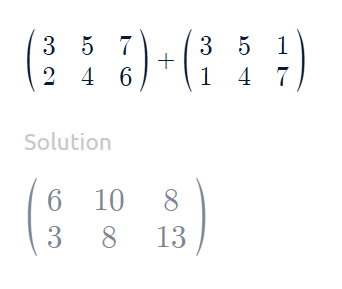

**Matrix substraction**
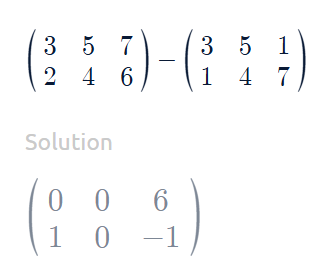

#### Matrix addition in python using above example

In [4]:
import numpy as np

# Define the first matrix (A)
A = np.array([[3, 5, 7],
              [2, 4, 6]])

# Define the second matrix (B)
B = np.array([[3, 5, 1],
              [1, 4, 7]])

# Perform matrix addition.
C = A + B

# Print the result
print(C)

[[ 6 10  8]
 [ 3  8 13]]


#### Matrix substraction in python using above example

In [3]:
import numpy as np

# Define the first matrix (A)
A = np.array([[3, 5, 7],
              [2, 4, 6]])

# Define the second matrix (B)
B = np.array([[3, 5, 1],
              [1, 4, 7]])

# Perform matrix addition.
C = A - B

# Print the result
print(C)

[[ 0  0  6]
 [ 1  0 -1]]


#### 2. Scalar multiplication
This is multiplying a matrix by a single number (called a scaler; a scaler is a single number that often represents size or magnitude with no dimensions of its own). 

Scalar multiplication can be viewed as expansion in all directions by a certain size; like blowing up a balloon.

*Example:*

**Scalar multiplication**
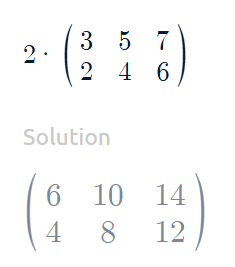

#### Scalar multiplication in python using above example

In [10]:
import numpy as np

# Define the matrix
A = np.array([[3, 5, 7],
              [2, 4, 6]])

# Perform matrix addition.
C = 2*A

# Print the result
print(C)

[[ 6 10 14]
 [ 4  8 12]]


#### 3. Matrix multiplication (dot product)
Matrix multiplication is just slightly more complicated/convoluted. When multiplying 2 matrices together the number of columns in matrix A must be the same number as the number of rows in matrix B.

Then **the process** is: multiply the rows of the first matrix by the columns of the second matrix (repeatedly moving onto the next columns then repeat with the next row) <br>

It is easier to illustrate graphically than to describe (as below):<br>
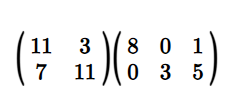
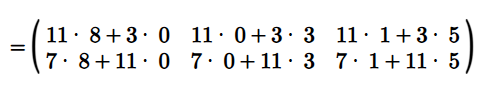

Note that matrix multiplication are not communitative like regular multiplication of integers e.g. $3\times4 = 4\times3$ but with matrices $AB \neq BA$ for obvious reasons order matters when you start switching matrices around proceeding in a different order can give different results.<br>

*Example:*
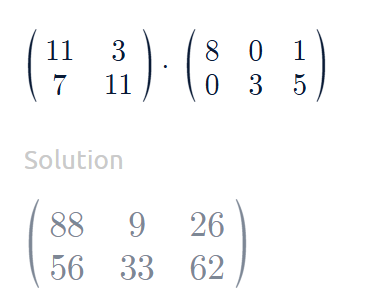



#### Matrix transposition in python using above example

In [3]:
import numpy as np

# Define the matrix
A = np.array([[11, 3],
              [7, 11]])

# Perform matrix addition.
B = np.array([[8, 0, 1],
              [0, 3, 5]])

C = np.dot(A,B)

# Print the result
print(C)

[[88  9 26]
 [56 33 62]]


#### 4. Transpose 

Matrix transposition is simply interchanging rows and columns i.e. flipping all the row elements into columns and consequently all the column elements into rows. Useful applications including the saving of space by being able to transpose long column matrices into more compact row matrices. An illustration is shown below for clarity: <br>
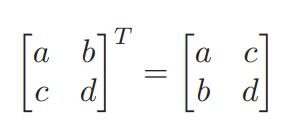

*Example:*

**Matrix transposition**

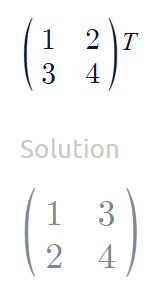


#### Matrix transpotion in python using above example

In [2]:
import numpy as np

# 1. Create the matrix
matrix = np.array([[1, 2], 
                   [3, 4]])

# 2. Perform the transposition
transpose_matrix = matrix.T

print("Original Matrix:")
print(matrix)

print("\nTransposed Matrix:")
print(transpose_matrix)

Original Matrix:
[[1 2]
 [3 4]]

Transposed Matrix:
[[1 3]
 [2 4]]


#### 5. Inverse of a matrix
The inverse of a matrix is sort of like the "opposite" of a matrix or more formally: when a matrix is multiplied by it's inverse you get the identity matrix.

*Example:*

**Inverse of a matrix**

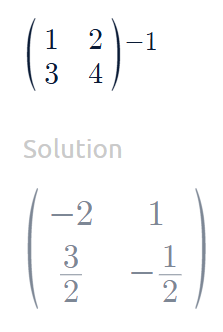 <br>

And then when you multiply the matrix by it's inverse you get the identity matrix: <br>
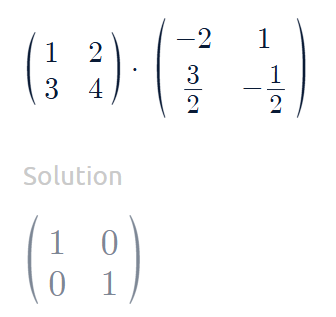 

Which is conceptually like multiplying any number by 1 which returns the original number e.g. <br>
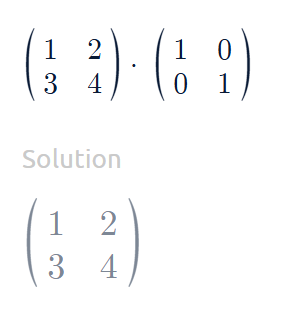

Consider the number $5$. It's inverse is $\dfrac{1}{5}$. Multiplying $5$ by it's inverse yields $1$ and multiplying 5 by this 'identity' yields back the original number $5$.

#### Matrix (find the inverse) in python using above example

In [5]:
import numpy as np

# Define the matrix
A = np.array([[1, 2],
              [3, 4]])

# Calculate the inverse
A_inv = np.linalg.inv(A)
print(A_inv)

[[-2.   1. ]
 [ 1.5 -0.5]]


#### Matrix multiplication by its inverse in python using above example

In [9]:
import numpy as np

# Define the matrix
A = np.array([[1, 2],
              [3, 4]])

# Perform matrix addition
B = np.array([[-2, 1],
              [1.5, -0.5]])

C = np.dot(A,B)
# C = A * B

# Print the result
print(C)

[[1. 0.]
 [0. 1.]]


#### Matrix multiplication by identity matrix in python using above example

In [11]:
import numpy as np

# Define the matrix
A = np.array([[1, 2],
              [3, 4]])

# Perform matrix addition
B = np.array([[1, 0],
              [0, 1]])

C = np.dot(A,B)
# C = A * B

# Print the result
print(C)

[[1 2]
 [3 4]]


###  3.3. Eigenvalues and Eigenvectors

Eigenvalues and Eigenvectors are scalars and vectors respectively which are associated with a matrix with heavy application in Physics, Mathematics in general and recently deep learning (part of machine learning) such as LLMs use these vectors extensively. 

*Eigenvalues: are simply numbers (scalars) with no other information for example speed tells us how fast a car is travelling but doesn't tell us in which direction it is travelling.*  

*Eigenvectors: is a value with other information such as direction for example a car travelling at 30mph south.*



### Eigenvectors in context

Normally we can use matrices to apply linear transformation on vectors in the cartessian coordinate system from say coordinates ($x_{0},y_{0}$) to coordinates ($x_{1},y_{1}$) as follows:

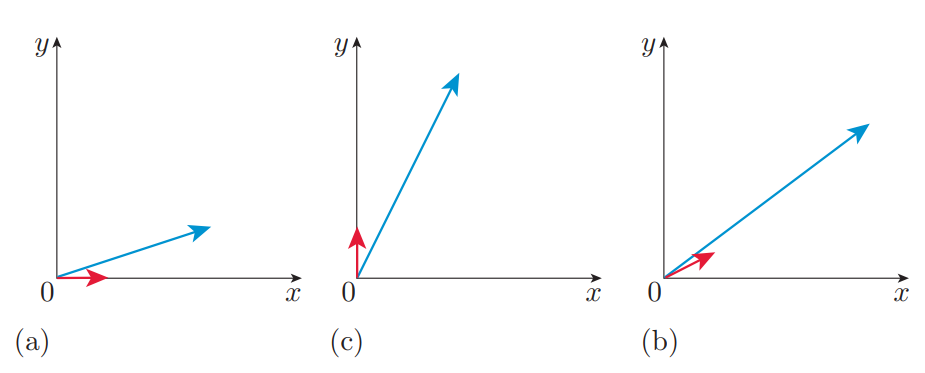

*Initial vector being red and transformed vector being blue*

The linear transformation would be applied using a standard matrix mulptilation with the format below:

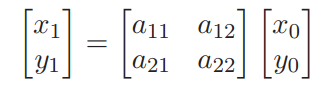

The point of a linear transformation on a general vector is to change its direction and magnitude.

However, there is one circumstance where the vector given only has it's magnitude changed but not it's direction.

Considering the following example:

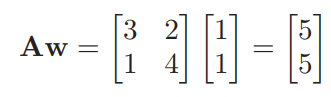

There is a vector matrix *w* which has linear transformation apllied via a square matrix *A*. It can be seen that the transformed vector is proportionally 5 times bigger than the initial vector *w* i.e. it's size (magnitude) has increased. Also, it can be seen that the direction really has not changed (see diagram below).

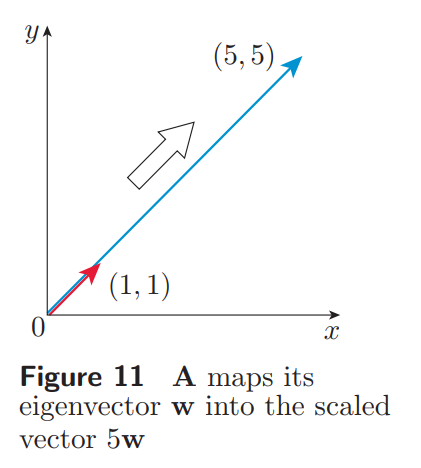

So this gets at the heart of what an Eigenvalue and an Eigenvector is:

**Eigenvalues are numbers (or scalars) that indicate how much a vector is scaled (or stretched) during a linear transformation, without changing its direction.**

**Eigenvectors on the other hand are vectors whose direction remains unchanged when a linear transformation is applied.**

In the example above *w* is an eigenvector of *A* which, corresponds to an eigenvalue of 5 and that's it!

Also, the square matrix can also have other eigenvectors and eigenvalues as below:

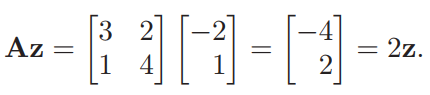

Here, the eigenvalue is 2 and the eigenvector is *z* (the eigenvector *z* basically scales by 2).

#### Below is the python code for performing the linear transformation of the example above

In [2]:
import numpy as np

# Define the Matrix A
A = np.array([[3, 2],
              [1, 4]])

# Define the Vector w
w = np.array([1, 1])

# Perform the Linear Transformation (Matrix Multiplication)
result = np.dot(A, w)

# Show the result
print("Matrix A:")
print(A)
print("\nVector w:")
print(w)
print("\nResult of Aw:")
print(result)

Matrix A:
[[3 2]
 [1 4]]

Vector w:
[1 1]

Result of Aw:
[5 5]


#### Getting the Eigenvalues and Eigenvectors of the above vector using Python

In [1]:
import numpy as np

# Define the Matrix A
A = np.array([[3, 2],
              [1, 4]])

# Calculate Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# Print the results
print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors (Normalized):")
print(eigenvectors)

Eigenvalues:
[2. 5.]

Eigenvectors (Normalized):
[[-0.89442719 -0.70710678]
 [ 0.4472136  -0.70710678]]


Note that the eigenvectors in this example have been normalised by Python (converted into unit vectors using Pythagorean theorem).

<b>A little bit about unit vectors...</b>

-------------------------------------------------------------------------------------------------------------------------------------------------------
The eigenvectors and eigenvalues of the above example are [1, 1] and [-2, 1] and 5 and 2 respectively. However, the decimals visible in the example are the result of standardisation by Python into unit vectors which have a value of 1. 

For example, vector [1, 1] is standardised by dividing each element by: $\sqrt{2}$

$\sqrt{1^{2} + 1^{2}} = \sqrt{2}$; *which stems from Pythagoras theorem i.e. the length of the longest side of a right-angled triangle*

$1/\sqrt{2} \approx 0.707$

-------------------------------------------------------------------------------------------------------------------------------------------------------

#### Denormalizing Eigenvectors of the above vector using Python

In [10]:
import numpy as np

# Define the Matrix A
A = np.array([[3, 2],
              [1, 4]])

# Get the normalized eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# De-normalize each column
# Divide each vector by its smallest element to find the integer ratio
denormalized_vectors = []
for i in range(len(eigenvalues)):
    # :take all rows, take the i-th column (splicing)
    vector = eigenvectors[:, i]
    print(vector)
    # Divide by the absolute smallest value to get simple numbers
    scaled_vector = vector / np.min(np.abs(vector))
    # print(np.min(np.abs(vector)))
    # scaled_vector = vector * np.sign(vector[0]) / np.min(np.abs(vector))
    #print(scaled_vector)
    denormalized_vectors.append(scaled_vector)

# 4. Print results
for i, val in enumerate(eigenvalues):
    print(f"Eigenvalue: {val}")
    print(f"De-normalized Eigenvector: {denormalized_vectors[i]}\n")

[-0.89442719  0.4472136 ]
[-0.70710678 -0.70710678]
Eigenvalue: 2.0
De-normalized Eigenvector: [-2.  1.]

Eigenvalue: 5.0
De-normalized Eigenvector: [-1. -1.]



Note that the eigenvector of [-1, -1] is legitimate (as opposed to [1, 1])  because it still scales by the same amount i.e. 5 and it's still on the same line but only in the negative direction. Eigenvectors are not necessarily unique as long as they have the same eigenvalue so [-1, -1] and [1, 1] both share the same eigenvalue.

## 4. Probability

### 4.1 What's the difference between probability and statistics?

<b>Probability</b> aims to predict uncertainty given certain know facts a priori for example the probability of picking a red sweet in a jar full of 10 sweets (7 red and 3 blue) is 7 in 10 or 70%.

<b>Statistics</b> on the other hand is about trying to find out about the level of uncertaintly for example running repeated experiments picking sweets out of the same jar might lead to the conclusion that there are more red sweets than blue sweets and to estimate the ratio to be roughly 7 to 10.

A more practical example might be something like mens height. Taking random samples might reveal something of a normal distribution where most men are 5ft 9 but some very few are above 6ft or below 5ft 4. This is both statistics and probability working together because the statistics is the sampling of men of different heights which can be used to reveal a normal probability distribution about the general population of men in general.

In very basic terms LLMs use probability to predict the next token (a word) in such a way that the probability of that next token is dependent on all the previous tokens (so called path dependent) i.e. the LLM calculates the probability distribution over the vocabulary for the next most probable token.





### 4.2 Probability distribution

Probability distributions, such as normal, binomial, uniform, etc., describe how data points are distributed. They allow for predicitons about a phenomena to be made if that phenomena fits with anyone of the aforemention probability distributions.

If observed data fits a particular probability distribution model then we can assign probability outcomes to a given random variable e.g. we can say that the probability of someone chosen at random being greater than a certain height is 40% or 50%

### 4.3 Normal distribution

**The Normal distribution example**

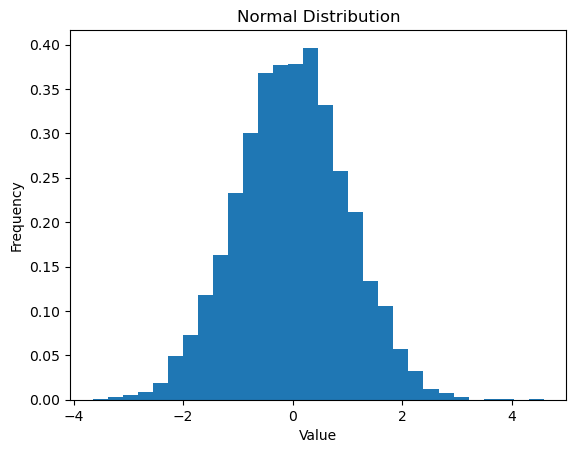

In [18]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

# generate a normal distribution
mean = 0
std_dev = 1
# generate a 10000 random numbers from a normal distribution
samples = np.random.normal(mean, std_dev, 10000)

# plot histogram
plt.hist(samples, bins=30, density=True)
plt.title('Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

The normal distribution is called Normal because it represents how most random variables in nature are distributed with a very common middle and a minority of extremes on either side. Height is typical of a normal distribution.

Properties of the normal distribution:

* It is symmetric about the mean
* Mean, Median and Mode are all equal and located in the centre
* 68, 95, 99.7 Rule i.e. 68% of the data falls within 1 standard deviation of the mean, 95% within 2 standard deviations and 99.7% within 3 standard deviations. Anything outside the band of 95% will be considered unusual or statistically significant e.g. the normal distribution can be used in hypothesis testing where broadly speaking a null hypothesis (no difference from some experiment) and althernative hypothesis (there is a difference from some experiment) are established and any random variable falling at the extreme ends of the distribution might lead to rejecting the null hypothesis and accepting the alternative hypothesis.



**The Normal distribution example with the 68, 95, 99.7 rule in Python**

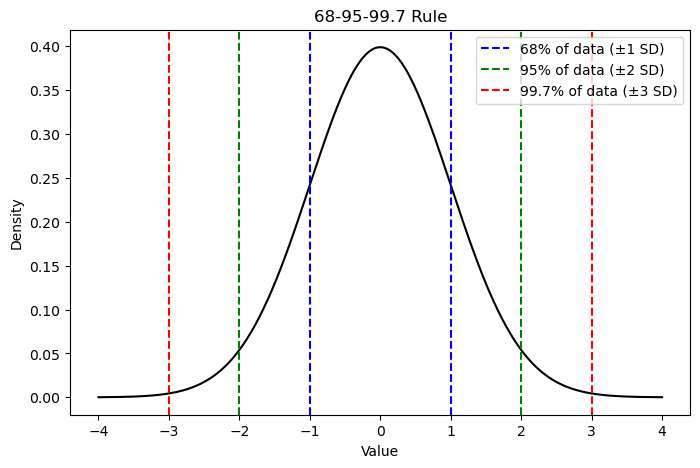

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate x values; with range and spacing i.e. 400 divisions
x = np.linspace(-4, 4, 400)

# Standard normal PDF with a mean of 0 and a standard deviation of one
y = norm.pdf(x, 0, 1)

# Plot the bell shaped curve with size 8 by 5
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='black')

# Define the mean and standard deviations
mu = 0
sigma = 1

# ±1, ±2, ±3 standard deviation lines. axvline draws vertical lines
plt.axvline(mu - 1*sigma, color='blue', linestyle='--', label='68% of data (±1 SD)')
plt.axvline(mu + 1*sigma, color='blue', linestyle='--')

plt.axvline(mu - 2*sigma, color='green', linestyle='--', label='95% of data (±2 SD)')
plt.axvline(mu + 2*sigma, color='green', linestyle='--')

plt.axvline(mu - 3*sigma, color='red', linestyle='--', label='99.7% of data (±3 SD)')
plt.axvline(mu + 3*sigma, color='red', linestyle='--')

# Labels and title
plt.title('68-95-99.7 Rule')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()

plt.show()

### 4.4 Bayes’ Theorem

Bayes' theorem is a way to update what we believe about something when we get new evidence. It helps us figure out the probability of an event based on prior knowledge of conditions that might be related to the event.

$P(A|B) = \dfrac{P(B|A) \cdot P(A)}{P(B)}$

$P(A|B)$: The probability of A happening, given that B already happened. (What we want to find out)<br>
$P(B|A)$: The probability of B happening, given that A happened<br>
$P(A)$: The probability of A happening before we knew about B<br>
$P(B)$: The probability of B happening in general<br>

**A walk through example demonstrates:**



There are two Jars (Jar 1 and Jar 2). Jar 1 has 30 blue sweets and 10 red sweets. Jar 2 has 20 blue sweets and 20 red sweets. Your friend asks you to pick any Jar and from that pick any sweet at random closing your eyes.

The question you want to know is: What is the probability of picking a red sweet given that it came from Jar 1 (updated information)?

Using the equation for Bayes' Theorem:

1. P(Jar 1=A) = 0.5
2. P(Red Sweet|Jar 1) = (10/40)
3. P(Red Sweet) = (10/40x1/2) + (20/40x1/2) = 0.375

This becomes (substituting into the equation):

$P(A|B) = \dfrac{P(0.25) \cdot P(0.5)}{P(0.375)} \approx 0.33$

Note that this is different from the probability of just picking a red sweet at random (0.375)
